# Cents: Air-Quality Demo

This notebook demonstrates how Cents processes, trains, generates, and evaluates contextual time series using the Beijing Multi-Site Air-Quality dataset.

The generated target is a **24-hour PM2.5 sequence** conditioned on:

- **Static context:** year, month, weekday, and monitoring station
- **Dynamic context:** hourly temperature, dew point, pressure, rain, and wind features

After installing [Cents](https://github.com/DAI-Lab/Cents) using the repository instructions, download the [demo files](https://drive.google.com/drive/folders/1ONCS1Y8nF1Hn6hETOGhU2i3v0wvd6YLH?usp=drive_link).

Extract the folders into these locations, relative to the repository root:

- `airquality` → `cents/data/airquality/`
- `beijing-reference-1000` → `runs/airquality/beijing-reference-1000/`

Place this notebook in `tutorials/` and select the repository’s Python environment.

## Setup

In [1]:
from pathlib import Path
import platform
import random
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from omegaconf import OmegaConf

REPO = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists() and (path / "cents").is_dir()
)
sys.path.insert(0, str(REPO))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("Repository:", REPO)
print("Python:", sys.executable)
print("Python version:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Selected device:", DEVICE)
print("Visible GPUs:", torch.cuda.device_count())
for index in range(torch.cuda.device_count()):
    print(f"  GPU {index}: {torch.cuda.get_device_name(index)}")


Repository: /home/sharvaa/MEng/Cents
Python: /home/sharvaa/MEng/Cents/.venv/bin/python
Python version: 3.12.3
PyTorch: 2.6.0+cu124
Selected device: cuda:0
Visible GPUs: 2
  GPU 0: NVIDIA TITAN RTX
  GPU 1: NVIDIA TITAN RTX


## Data

The raw data contain one row per station and hour.

In [2]:
DATA_DIR = REPO / "cents/data/airquality"
csv_paths = sorted(DATA_DIR.glob("PRSA_Data_*.csv"))

if not csv_paths:
    raise FileNotFoundError(f"No Beijing station CSV files found in {DATA_DIR}")

raw = pd.read_csv(csv_paths[0])

print("Station files:", len(csv_paths))
print("Example file:", csv_paths[0].name)
print("Hourly rows:", len(raw))
display(raw.head())

Station files: 12
Example file: PRSA_Data_Aotizhongxin_20130301-20170228.csv
Hourly rows: 35064


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


`AirQualityDataset` converts the hourly records into the format expected by Cents. Each processed row contains:

- fixed-length target sequence
- fixed-length sequence for each dynamic context variable
- one value for each static context variable

For our Beijing dataset, this is a 24-hour PM2.5 target, one year/month/weekday/station value, and 24 hourly values for each weather variable.

In [3]:
from cents.datasets.airquality import AirQualityDataset

dataset_cfg = OmegaConf.load(REPO / "cents/config/dataset/airquality.yaml")
dataset_cfg.normalize = False
dataset_cfg.max_samples = None

dataset = AirQualityDataset(cfg=dataset_cfg)

print("Daily samples:", len(dataset))
print("Sequence length:", dataset.seq_len)
print("Target columns:", dataset.time_series_column_names)
print("Static context:", dataset.static_context_vars)
print("Dynamic context:", dataset.dynamic_context_vars)

/home/sharvaa/MEng/Cents/cents/datasets/airquality.py:226: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask = data[numeric_series].applymap(is_all_nan).any(axis=1) if numeric_series else pd.Series([False] * len(data))


Computing rarity features...
Saved rarity cache to /home/sharvaa/MEng/Cents/cents/cache/rarity/rarity_05efbf11.pkl
Daily samples: 15143
Sequence length: 24
Target columns: ['PM2.5']
Static context: ['year', 'month', 'weekday', 'station']
Dynamic context: ['TEMP', 'DEWP', 'PRES', 'RAIN', 'wind_u', 'wind_v', 'wd_valid']


In [4]:
display(dataset.data.head(3))

,index,station,year,month,day,weekday,TEMP,DEWP,PRES,RAIN,wind_u,wind_v,wd_valid,timeseries,is_frequency_rare,cluster,is_pattern_rare,is_rare
0,0,0,0,2,1,4,"(-1.2441293, -1.2790676, -1.2790676, -1.305271...","(-1.5424708, -1.49916, -1.49916, -1.5857818, -...","(1.1745247, 1.1936628, 1.2223669, 1.3180516, 1...","(-0.13943078, -0.13943078, -0.13943078, -0.139...","(2.5756197, 3.0006819, 3.3178244, 1.3216875, 1...","(-1.0684929, 0.06314144, -1.3771205, -1.410054...","(0.06561492, 0.06561492, 0.06561492, 0.0656149...","[[4.0], [8.0], [7.0], [6.0], [3.0], [5.0], [3....",False,4,True,False
1,1,0,0,2,2,5,"(-1.2179257, -1.270333, -1.3140059, -1.3052713...","(-1.4558492, -1.4341936, -1.4053197, -1.455849...","(1.9400014, 1.9687114, 1.9304352, 1.9017252, 1...","(-0.13943078, -0.13943078, -0.13943078, -0.139...","(0.21287179, 0.5345563, -0.14579806, 0.7201075...","(0.9324164, 0.34605002, 1.2056586, 0.42320693,...","(0.06561492, 0.06561492, 0.06561492, 0.0656149...","[[22.0], [14.0], [13.0], [3.0], [3.0], [9.0], ...",False,0,False,False
2,2,0,0,2,3,6,"(-1.3052713, -1.3576788, -1.4275552, -1.410086...","(-1.123799, -1.1382359, -1.0732697, -1.1382359...","(0.9257471, 0.83006257, 0.724806, 0.6195553, 0...","(-0.13943078, -0.13943078, -0.13943078, -0.139...","(0.5964067, 0.42226088, 0.5169373, 0.42226088,...","(0.37176898, 0.63341075, 0.72845566, 0.6334107...","(0.06561492, 0.06561492, 0.06561492, 0.0656149...","[[112.0], [109.0], [110.0], [105.0], [106.0], ...",False,2,True,False


Categorical variables are encoded during pre-processing

In [5]:
context_codes = dataset.get_context_var_codes()
selected_rows = np.linspace(0, len(dataset) - 1, 5, dtype=int)

static_rows = dataset.data.loc[
    selected_rows, dataset.static_context_vars
].copy()

print("Static context codes")
display(static_rows)

for name in dataset.static_context_vars:
    static_rows[name] = static_rows[name].map(context_codes[name])

print("Decoded static context")
display(static_rows)

Static context codes


,year,month,weekday,station
0,0,2,4,0
3785,4,1,6,2
7571,4,0,4,5
11356,0,3,0,9
15142,4,1,1,11


Decoded static context


,year,month,weekday,station
0,2013,March,Friday,Aotizhongxin
3785,2017,February,Sunday,Dingling
7571,2017,January,Friday,Gucheng
11356,2013,April,Monday,Tiantan
15142,2017,February,Tuesday,Wanshouxigong


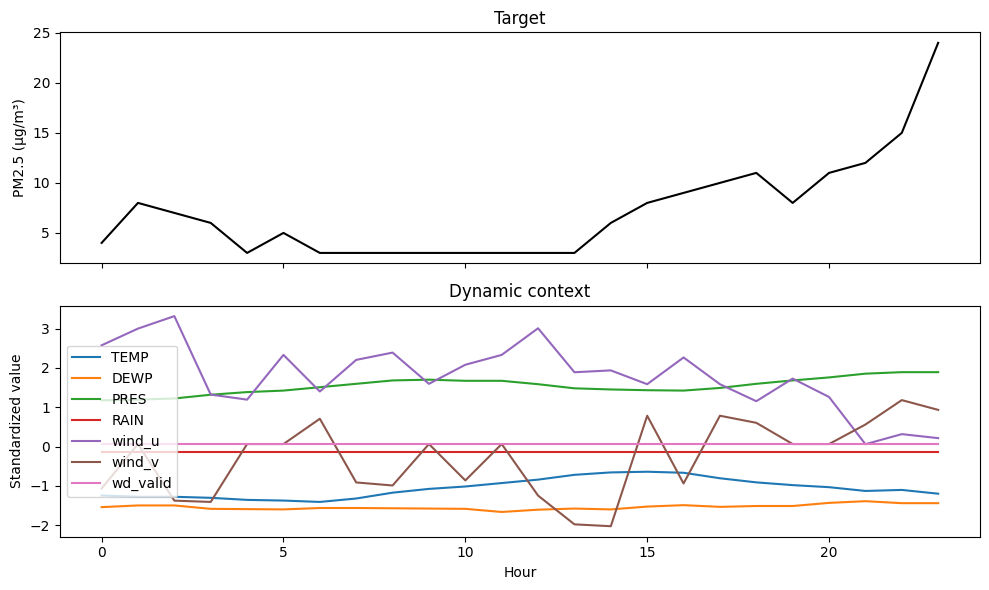

In [6]:
target, static_context, dynamic_context = dataset[0]

hours = np.arange(dataset.seq_len)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(hours, target.squeeze().numpy(), color="black")
axes[0].set(title="Target", ylabel="PM2.5 (µg/m³)")

pd.DataFrame({
    name: values.numpy() for name, values in dynamic_context.items()
}).plot(ax=axes[1])

axes[1].set(
    title="Dynamic context",
    xlabel="Hour",
    ylabel="Standardized value",
)

plt.tight_layout()
plt.show()


PM2.5 (Target) is shown in physical units. Dynamic context is standardized during preprocessing.

## Loading Pre-trained Model
This section requires the earlier-downloaded `beijing-reference-1000` run folder. The reference model was trained on the full Beijing dataset using:

- **Model:** Diffusion-TS with 1,000 diffusion steps
- **Context:** MLP static encoder and transformer dynamic encoder
- **Training:** 1,000 epochs on one GPU with mixed precision
- **Batch size:** 512, with gradient accumulation over 4 batches
- **Optimizer:** Adam, learning rate `1e-4`, betas `(0.9, 0.96)`
- **Schedule:** 100 warmup epochs, followed by ReduceLROnPlateau
- **Loss weights:** static-context reconstruction `0.1`, Fourier `0.1`, total correlation `0`
- **Normalization:** learned station-conditioned target normalization
- **EMA:** decay `0.999`
- **Checkpoint evaluation:** Context-FID every 20 epochs using 1,000 samples and 20 DDIM steps
- **Random seed:** 42

In [7]:
from cents.data_generator import DataGenerator
from cents.utils.utils import set_context_config_path, set_context_overrides

REFERENCE_RUN = REPO / "runs/airquality/beijing-reference-1000"

set_context_config_path(str(REFERENCE_RUN / "config/context.yaml"))
set_context_overrides([])

reference_cfg = OmegaConf.create({
    name: OmegaConf.load(REFERENCE_RUN / f"config/{name}.yaml")
    for name in ["model", "dataset"]
})
reference_cfg.model.use_ema_sampling = False # Saved EMA restoration is disabled currently in the repo

reference = DataGenerator(
    model_type="diffusion_ts", dataset=dataset, cfg=reference_cfg,
)
reference.load_from_checkpoint(
    REFERENCE_RUN / "checkpoints/last.ckpt",
    next((REFERENCE_RUN / "normalizer").glob("*.ckpt")),
)


[Cents] Loading full checkpoint (weights + metadata) from /home/sharvaa/MEng/Cents/runs/airquality/beijing-reference-1000/checkpoints/last.ckpt. Use `.pt` for safer minimal loading.
[Cents] Loading model from checkpoint: /home/sharvaa/MEng/Cents/runs/airquality/beijing-reference-1000/checkpoints/last.ckpt
Using custom context config path: /home/sharvaa/MEng/Cents/runs/airquality/beijing-reference-1000/config/context.yaml
{'year': ['categorical', 5], 'month': ['categorical', 12], 'weekday': ['categorical', 7], 'station': ['categorical', 12]}
[EMA] No EMA weights in checkpoint, initializing fresh
Using custom context config path: /home/sharvaa/MEng/Cents/runs/airquality/beijing-reference-1000/config/context.yaml
[Normalizer] Found 7 context module parameters
[Normalizer] Found 12 stats head parameters
[Normalizer] Total trainable parameters: 1,255,310


In [8]:
ROW = 0
N = 4

def sample(model, normalizer, dynamic_row=None, seed=None):
    _, static, dynamic = dataset[ROW]
    if dynamic_row is not None:
        _, _, dynamic = dataset[dynamic_row]
    device = next(model.parameters()).device
    static = {k: v.repeat(N).to(device) for k, v in static.items()}
    dynamic = {k: v.repeat(N, 1).to(device) for k, v in dynamic.items()}

    if seed is not None:
        torch.manual_seed(seed)
    model.eval()
    with torch.no_grad():
        generated = model.generate(static, dynamic)

    frame = dataset.data.iloc[[ROW] * N].copy().reset_index(drop=True)
    if dynamic_row is not None:
        for name in dataset.dynamic_context_vars:
            frame[name] = [dataset.data.iloc[dynamic_row][name]] * N
    frame["timeseries"] = list(generated.cpu().numpy())
    return np.stack(normalizer.inverse_transform(frame)["PM2.5"]).reshape(N, -1)


[CENTS] Generating samples:   0%|          | 0/1 [00:00<?, ?seq/s]

Inverse normalizing: 100%|██████████| 4/4 [00:00<00:00, 1008.55it/s]


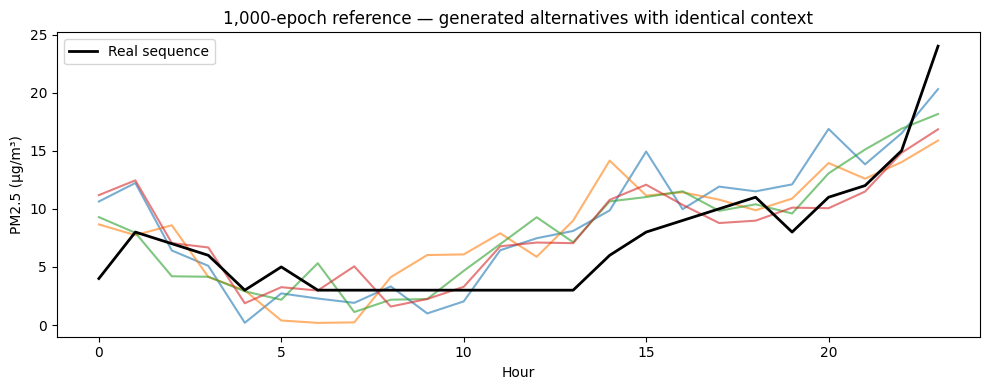

In [9]:
reference_samples = sample(reference.model, reference.normalizer)

plt.figure(figsize=(10, 4))

plt.plot(reference_samples.T, alpha=0.6)
plt.plot(
    dataset[ROW][0].squeeze().numpy(),
    color="black",
    linewidth=2,
    label="Real sequence",
)

plt.title("1,000-epoch reference — generated alternatives with identical context")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()

Fixed static context:
  year: 2013
  month: March
  weekday: Friday
  station: Aotizhongxin

Weather source rows: 0 and 1


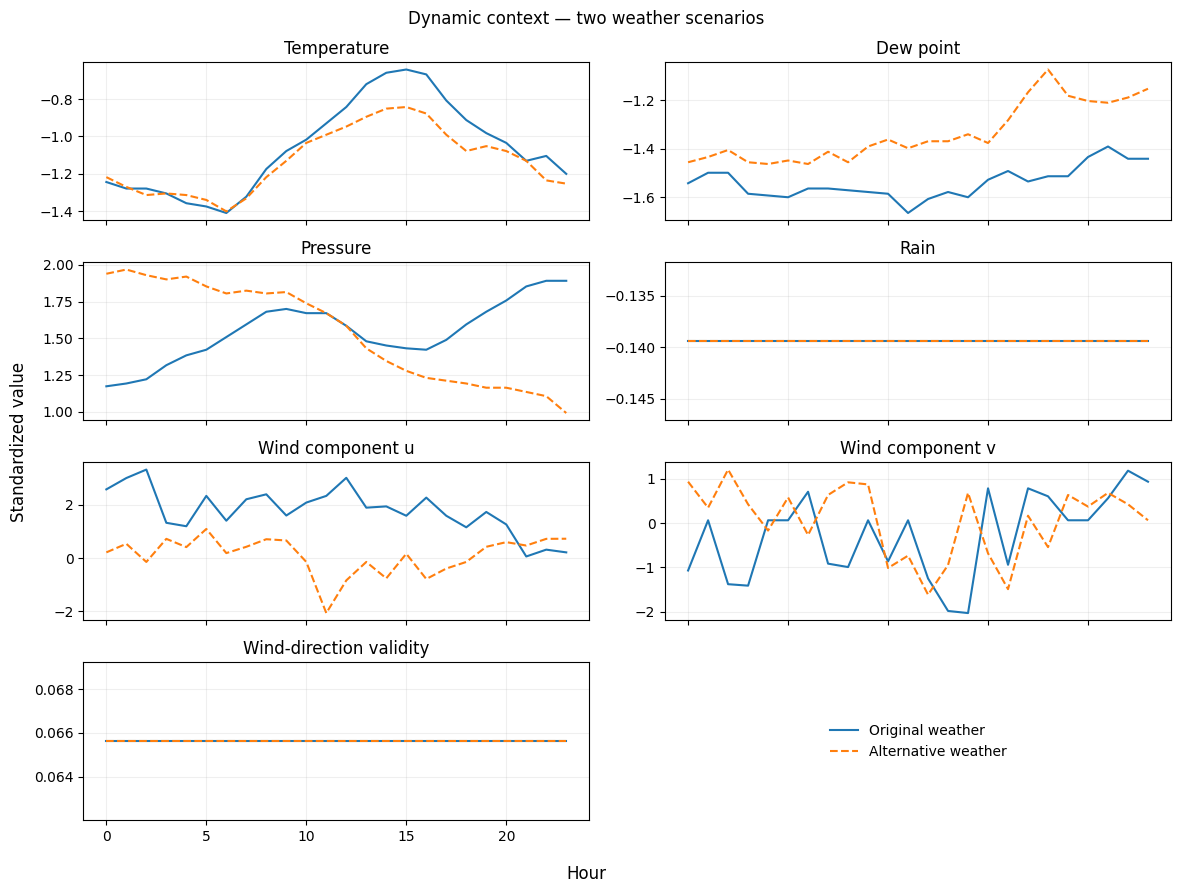

[CENTS] Generating samples:   0%|          | 0/1 [00:00<?, ?seq/s]

Inverse normalizing: 100%|██████████| 4/4 [00:00<00:00, 1192.92it/s]


[CENTS] Generating samples:   0%|          | 0/1 [00:00<?, ?seq/s]

Inverse normalizing: 100%|██████████| 4/4 [00:00<00:00, 1134.06it/s]


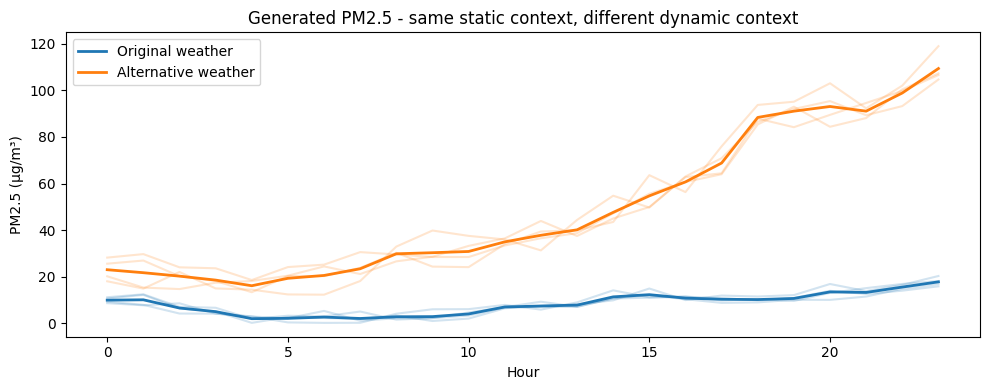

In [10]:
WEATHER_ROW = 1

# Show the fixed static context.
_, static, original_weather = dataset[ROW]
_, _, alternative_weather = dataset[WEATHER_ROW]
codes = dataset.get_context_var_codes()

print("Fixed static context:")
for name, value in static.items():
    code = value.item()
    print(f"  {name}: {codes.get(name, {}).get(code, code)}")

print(f"\nWeather source rows: {ROW} and {WEATHER_ROW}")

labels = {
    "TEMP": "Temperature",
    "DEWP": "Dew point",
    "PRES": "Pressure",
    "RAIN": "Rain",
    "wind_u": "Wind component u",
    "wind_v": "Wind component v",
    "wd_valid": "Wind-direction validity",
}

fig, axes = plt.subplots(4, 2, figsize=(12, 9), sharex=True)
hours = np.arange(dataset.seq_len)

for ax, name in zip(axes.flat, original_weather):
    ax.plot(hours, original_weather[name].numpy(),
            color="C0", label="Original weather")
    ax.plot(hours, alternative_weather[name].numpy(),
            color="C1", linestyle="--", label="Alternative weather")
    ax.set_title(labels.get(name, name))
    ax.grid(alpha=0.2)

# Use the unused panel for the shared legend.
axes.flat[-1].axis("off")
handles, legend_labels = axes.flat[0].get_legend_handles_labels()
axes.flat[-1].legend(handles, legend_labels, loc="center", frameon=False)

fig.suptitle("Dynamic context — two weather scenarios")
fig.supxlabel("Hour")
fig.supylabel("Standardized value")
plt.tight_layout()
plt.show()

# Generate with identical static context and random noise.
original_weather_samples = sample(
    reference.model, reference.normalizer, seed=SEED,
)
changed_weather_samples = sample(
    reference.model, reference.normalizer,
    dynamic_row=WEATHER_ROW, seed=SEED,
)

plt.figure(figsize=(10, 4))

for samples, color, label in [
    (original_weather_samples, "C0", "Original weather"),
    (changed_weather_samples, "C1", "Alternative weather"),
]:
    plt.plot(samples.T, color=color, alpha=0.2)
    plt.plot(samples.mean(axis=0), color=color, linewidth=2, label=label)

plt.title("Generated PM2.5 - same static context, different dynamic context")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()

## Model Evaluation

Cents compares generated sequences with real data using a few metrics including:

- Distribution and sequence similarity between real and generated data: DTW, MMD, Banded MSE, Context-FID, and Discriminative Score
- Utility metrics: Predictive Score (TSTR MAE), compared with the real-data baseline (TRTR MAE)
- Preservation of relationships between variables: Context Faithfulness Score (CFS) and Granger Causality Preservation (GCP)

We evaluate **512 samples** to demonstrate the pipeline.

In [11]:
from cents.eval.eval import Evaluator

evaluation_cfg = OmegaConf.create({
    "eval_metrics": True,
    "pred_score_trtr": True,
    "eval_context_sparse": False,
    "eval_disentanglement": False,
    "eval_context_recovery": False,
    "eval_context_faithfulness": {
        "enabled": True,
        "gcp_max_lag": 5,
        "pairs": [
            {"x": "PM2.5", "c": "TEMP"},
            {"x": "PM2.5", "c": "DEWP"},
        ],
    },
    "save_results": True,
    "save_dir": str(REFERENCE_RUN / "evaluation"),
})

indices = np.random.default_rng(SEED).choice(
    len(dataset), size=512, replace=False,
)


In [12]:
from copy import copy

# Prepare the same subset using the reference model's normalizer on the unnormalized dataset.
reference_data = copy(dataset)
reference_data.data = dataset.data.iloc[indices].copy().reset_index(drop=True)
reference_data._normalizer = reference.normalizer
reference_data.apply_pretrained_normalizer()
reference_data.normalize = True

reference_eval_cfg = OmegaConf.create({
    "model": reference.cfg.model,
    "dataset": reference.cfg.dataset,
    "evaluator": evaluation_cfg,
    "device": str(next(reference.model.parameters()).device),
})
reference_eval_cfg.evaluator.save_dir = str(REFERENCE_RUN / "evaluation")

evaluator = Evaluator(reference_eval_cfg, reference_data)
reference_results = evaluator.evaluate_model(model=reference.model)

print(json.dumps(reference_results["metrics"], indent=2))


Normalizing: 100%|██████████| 512/512 [00:00<00:00, 1383.10it/s]

[CENTS] Using device: cuda:0 for evaluation


[CENTS] Generating samples:   0%|          | 0/1 [00:00<?, ?seq/s]

Inverse normalizing: 100%|██████████| 512/512 [00:00<00:00, 1457.93it/s]


(512, 24, 1) (512, 24, 1)


...

(512, 24, 1) (512, 24, 1)


[Cents] Training Discriminative Score Model:   0%|          | 0/2000 [00:00<?, ?it/s]

[Cents] Training Predictive Score Model:   0%|          | 0/5000 [00:00<?, ?it/s]

[Cents] Training Predictive Score Model:   0%|          | 0/5000 [00:00<?, ?it/s]

{
  "DTW": {
    "mean": 40.716563786040005,
    "std": 22.805630404935716
  },
  "MMD": {
    "mean": 0.08408112334074404,
    "std": 0.029125151693204423
  },
  "Banded_MSE": {
    "band_1": {
      "mean": 136.32440315160025,
      "std": 826.9105711580197,
      "range": [
        2.0,
        17.0
      ]
    },
    "band_2": {
      "mean": 90.58906044407689,
      "std": 201.34646102497553,
      "range": [
        17.0,
        41.0
      ]
    },
    "band_3": {
      "mean": 174.64848798219876,
      "std": 373.0023617575354,
      "range": [
        41.0,
        76.0
      ]
    },
    "band_4": {
      "mean": 242.96256635024787,
      "std": 504.9338304170082,
      "range": [
        76.0,
        135.0
      ]
    },
    "band_5": {
      "mean": 388.9007708645124,
      "std": 782.1375200585999,
      "range": [
        135.0,
        762.0
      ]
    }
  },
  "Context_FID": 7.855884895359324,
  "Disc_Score": 0.0490196078431373,
  "Pred_Score": {
    "tstr_mae": 72.88

## Training From Scratch

**Before training:** If using PyTorch 2.6, remove `verbose: false` from
`lr_scheduler_params` in `cents/config/trainer/diffusion_ts.yaml`, if present.
`Trainer` loads this file automatically.

We do a short training run to demonstrate the pipeline. Typically this will be done by calling `scripts/train.py`.

In [ ]:
from cents.trainer import Trainer
from cents.utils.utils import (
    get_normalizer_training_config,
    set_context_overrides,
)
import cents.datasets.timeseries_dataset as timeseries_dataset_module

TUTORIAL_EPOCHS = 3
TUTORIAL_RUN = REPO / "runs/airquality/airquality-tutorial"

# Use one GPU when the learned normalizer is trained inside Jupyter.
def notebook_normalizer_config():
    cfg = get_normalizer_training_config()
    cfg.devices = 1
    cfg.strategy = "auto"
    return cfg


timeseries_dataset_module.get_normalizer_training_config = (
    notebook_normalizer_config
)

# Include hourly weather variables in the model.
set_context_config_path(None)
set_context_overrides([
    "dynamic_context.type=transformer",
])

# Create a second copy of the dataset with target normalization enabled.
training_cfg = OmegaConf.load(
    REPO / "cents/config/dataset/airquality.yaml"
)
training_cfg.normalize = True
training_cfg.max_samples = None

training_dataset = AirQualityDataset(
    cfg=training_cfg,
    run_dir=str(TUTORIAL_RUN),
)


trainer = Trainer(
    model_type="diffusion_ts",
    dataset=training_dataset,
    overrides=[
        f"run_dir={TUTORIAL_RUN}",
        f"trainer.max_epochs={TUTORIAL_EPOCHS}",
        "trainer.devices=1",
        "trainer.strategy=auto",
        "trainer.intermediate_fid.enabled=false",
    ],
)

trainer.fit()


/home/sharvaa/MEng/Cents/cents/datasets/airquality.py:226: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask = data[numeric_series].applymap(is_all_nan).any(axis=1) if numeric_series else pd.Series([False] * len(data))


Applied context config overrides: ['dynamic_context.type=transformer']
[Cents] cache_path: /home/sharvaa/MEng/Cents/runs/airquality/airquality-tutorial/normalizer/airquality_normalizer_dim1_ctxmlp_statsmlp_dyntransformer.ckpt
[Normalizer] Found 7 context module parameters
[Normalizer] Found 12 stats head parameters
[Normalizer] Total trainable parameters: 1,255,310
[Cents] Loaded normalizer from /home/sharvaa/MEng/Cents/runs/airquality/airquality-tutorial/normalizer/airquality_normalizer_dim1_ctxmlp_statsmlp_dyntransformer.ckpt
Applied context config overrides: ['dynamic_context.type=transformer']
[Main Process] Loading pre-normalized data from cache /home/sharvaa/MEng/Cents/runs/airquality/airquality-tutorial/cache/normalized_data/normalized_7b34baf1.pkl
Computing rarity features...


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/sharvaa/MEng/Cents/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:658: Checkpoint directory /home/sharvaa/MEng/Cents/runs/airquality/airquality-tutorial/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                   | Type                             | Params | Mode 
------------------------------------------------------------------------------------
0 | static_context_module  | MLPContextModule                 | 45.8 K | train
1 | dynamic_context_module | DynamicContextModule_Transformer | 741 K  | train
2 | context_embed_dropout  | Dropout                          | 0      | train
3 | fc                     | Linear                           | 2      | train
4 | model                  | Transformer                      | 3.4 M  | train
5 | 

Applied context config overrides: ['dynamic_context.type=transformer']
Saved rarity cache to /home/sharvaa/MEng/Cents/runs/airquality/airquality-tutorial/cache/rarity/rarity_05efbf11.pkl
Applied context config overrides: ['dynamic_context.type=transformer']
{'year': ['categorical', 5], 'month': ['categorical', 12], 'weekday': ['categorical', 7], 'station': ['categorical', 12]}
Applied context config overrides: ['dynamic_context.type=transformer']
Saving every 250 epochs (if configured)
[Cents] Training model on 30 batches


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


Generate a few samples. The quality will be low since we trained for such few epochs.

In [14]:
short_samples = sample(trainer.model, training_dataset._normalizer)


[CENTS] Generating samples:   0%|          | 0/1 [00:00<?, ?seq/s]

Inverse normalizing: 100%|██████████| 4/4 [00:00<00:00, 1040.19it/s]


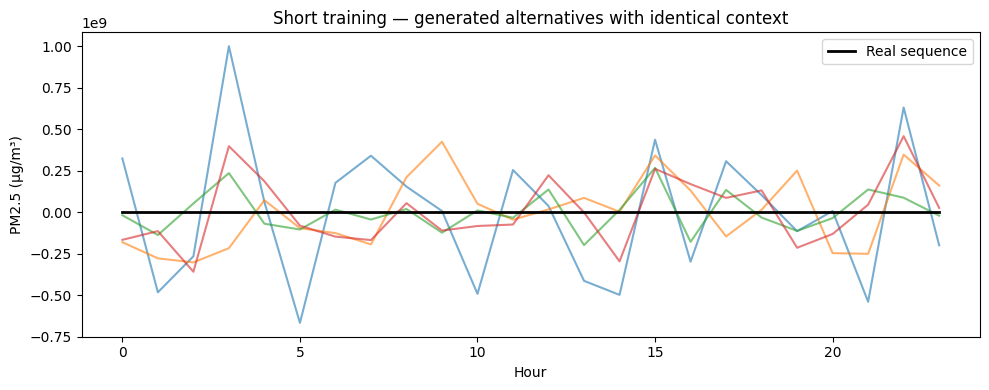

In [15]:
plt.figure(figsize=(10, 4))

plt.plot(short_samples.T, alpha=0.6)
plt.plot(
    dataset[ROW][0].squeeze().numpy(),
    color="black",
    linewidth=2,
    label="Real sequence",
)

plt.title("Short training — generated alternatives with identical context")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()

We now evaluate on the same 512 samples.

In [16]:
trainer.cfg.evaluator = OmegaConf.create(
    OmegaConf.to_container(evaluation_cfg, resolve=True)
)
trainer.cfg.evaluator.save_dir = str(TUTORIAL_RUN / "evaluation")

evaluator = Evaluator(trainer.cfg, training_dataset)
trainer.model.to(evaluator.device).eval()
evaluator.evaluate_subset(training_dataset, trainer.model, indices)

results = evaluator.current_results
evaluator.save_results()

print(json.dumps(results["metrics"], indent=2))


[CENTS] Using device: cuda for evaluation


[CENTS] Generating samples:   0%|          | 0/1 [00:00<?, ?seq/s]

Inverse normalizing: 100%|██████████| 512/512 [00:00<00:00, 1535.48it/s]


(512, 24, 1) (512, 24, 1)


[Cents] Training Discriminative Score Model:   0%|          | 0/2000 [00:00<?, ?it/s]

...

(512, 24, 1) (512, 24, 1)


[Cents] Training Discriminative Score Model:   0%|          | 0/2000 [00:00<?, ?it/s]

[Cents] Training Predictive Score Model:   0%|          | 0/5000 [00:00<?, ?it/s]

[Cents] Training Predictive Score Model:   0%|          | 0/5000 [00:00<?, ?it/s]

{
  "DTW": {
    "mean": 1798341539.1730914,
    "std": 3204583483.45725
  },
  "MMD": {
    "mean": 0.14098128184012781,
    "std": 0.054794005995466216
  },
  "Banded_MSE": {
    "band_1": {
      "mean": 4.801082771297095e+17,
      "std": 2.4935190824579886e+18,
      "range": [
        2.0,
        17.0
      ]
    },
    "band_2": {
      "mean": 2.6559492900596586e+17,
      "std": 9.647576451806065e+17,
      "range": [
        17.0,
        41.0
      ]
    },
    "band_3": {
      "mean": 4.9660249474338874e+17,
      "std": 3.176144190996345e+18,
      "range": [
        41.0,
        76.0
      ]
    },
    "band_4": {
      "mean": 6.23677931129365e+17,
      "std": 3.6329558136978857e+18,
      "range": [
        76.0,
        135.0
      ]
    },
    "band_5": {
      "mean": 6.78047925486228e+17,
      "std": 4.875027851042979e+18,
      "range": [
        135.0,
        762.0
      ]
    }
  },
  "Context_FID": 1.312322723696656e+18,
  "Disc_Score": 0.4901960784313726,